# Load Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pygenelab as pgl

In [28]:
import os
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import decoupler as dc

# Constants

In [5]:
MICE_DATASET_PATH = (
    r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/"
    r"integrated_samples/objects/adata_harmony_celloracle_compatible_v2.h5ad"
)

In [38]:
PATHWAY_TYPE = "METABOLISM"
PATHWAY_KEYWORDS = ["METABOLISM"]

In [7]:
MALE_DEGS_DIR = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/male/degs"
FEMALE_DEGS_DIR = r"/ocean/projects/cis240075p/asachan/datasets/TA_muscle/ERCC1_KO_mice/integrated_samples/analysis/female/degs"
MALE_FASTIIX_DEGS_PATH = os.path.join(MALE_DEGS_DIR, "DEGs_KO_vs_WT_Fast_IIX.csv")
MALE_FASTIIB_DEGS_PATH = os.path.join(MALE_DEGS_DIR, "DEGs_KO_vs_WT_Fast_IIB.csv")
FEMALE_FASTIIX_DEGS_PATH = os.path.join(FEMALE_DEGS_DIR, "DEGs_KO_vs_WT_Fast_IIX.csv")
FEMALE_FASTIIB_DEGS_PATH = os.path.join(FEMALE_DEGS_DIR, "DEGs_KO_vs_WT_Fast_IIB.csv")

In [8]:
MSIGDB_MICE_PATHWAYS_GMT = "/ocean/projects/cis240075p/asachan/datasets/gene_sets/mouse/msigdb.v2024.1.Mm.symbols.gmt"

In [16]:
PATHWAY_MIN = 15
PATHWAY_MAX = 500

In [47]:
OUTPUT_DIR = "Output"

# Util Functions

In [9]:
def create_ranked_genelist(deg_df, log2fc_col='logfoldchanges', pval_col='pvals_adj', gene_col='gene_name', min_pval=1e-300):
    """
    create a ranked gene list based on signed log2FC * -log10(adjusted p-value)
    """
    df = deg_df.copy()

    # clip p-values
    df[pval_col] = df[pval_col].clip(lower=min_pval)

    # calculate components and final score
    df['neg_log10_pval'] = -np.log10(df[pval_col])
    df['ranking_score'] = df[log2fc_col] * df['neg_log10_pval']

    # sort by absolute ranking score
    ranked_df = df.sort_values('ranking_score', ascending=False)
    
    # create final DataFrame with gene names as columns
    ranked_list = ranked_df.set_index(gene_col)[['ranking_score']].T
    return ranked_list

In [41]:
def plot_pathway_heatmap(df_iix, df_iib, common_pathways, title="Pathway Enrichment"):
    # filter
    df_iix = df_iix[df_iix["Term"].isin(common_pathways)].copy()
    df_iib = df_iib[df_iib["Term"].isin(common_pathways)].copy()

    # use -log10(pval)
    df_iix["score"] = df_iix["-log10(pval)"]
    df_iib["score"] = df_iib["-log10(pval)"]

    # split
    df_iix_up = df_iix[df_iix["Group"] == "Up"]
    df_iix_down = df_iix[df_iix["Group"] == "Down"]

    df_iib_up = df_iib[df_iib["Group"] == "Up"]
    df_iib_down = df_iib[df_iib["Group"] == "Down"]

    # merge
    up_merged = pd.merge(
        df_iix_up[["Term", "score"]],
        df_iib_up[["Term", "score"]],
        on="Term",
        suffixes=("_IIX", "_IIB")
    ).set_index("Term")

    down_merged = pd.merge(
        df_iix_down[["Term", "score"]],
        df_iib_down[["Term", "score"]],
        on="Term",
        suffixes=("_IIX", "_IIB")
    ).set_index("Term")

    # sort
    if not up_merged.empty:
        up_merged = up_merged.sort_values("score_IIX", ascending=False)
    if not down_merged.empty:
        down_merged = down_merged.sort_values("score_IIX", ascending=False)

    # figure
    fig = plt.figure(figsize=(6, (len(up_merged) + len(down_merged)) * 0.5 + 2))

    gs = fig.add_gridspec(
        nrows=2, ncols=2,
        width_ratios=[20, 1],
        height_ratios=[max(len(up_merged), 1), max(len(down_merged), 1)],
        hspace=0.3
    )

    # up heatmap
    if not up_merged.empty:
        ax_up = fig.add_subplot(gs[0, 0])
        cbar_ax_up = fig.add_subplot(gs[0, 1])

        im_up = ax_up.imshow(
            up_merged.values,
            aspect="auto",
            cmap="Reds",
            vmin=0,
            vmax=up_merged.values.max()
        )

        # labels
        ax_up.set_xticks([0, 1])
        ax_up.set_xticklabels(["IIX", "IIB"], fontsize=12)

        ax_up.set_yticks(range(len(up_merged)))
        ax_up.set_yticklabels(up_merged.index, fontsize=10)

        ax_up.set_title("Upregulated Pathways", fontsize=12, fontweight="bold")

        # borders
        ax_up.set_xticks(np.arange(-0.5, 2, 1), minor=True)
        ax_up.set_yticks(np.arange(-0.5, len(up_merged), 1), minor=True)
        ax_up.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
        ax_up.tick_params(which="minor", bottom=False, left=False)

        # colorbar
        cbar_up = plt.colorbar(im_up, cax=cbar_ax_up)
        cbar_up.set_label("-log10(pval)")

    # down heatmap
    if not down_merged.empty:
        ax_down = fig.add_subplot(gs[1, 0])
        cbar_ax_down = fig.add_subplot(gs[1, 1])

        im_down = ax_down.imshow(
            down_merged.values,
            aspect="auto",
            cmap="Blues",
            vmin=0,
            vmax=down_merged.values.max()
        )

        # labels
        ax_down.set_xticks([0, 1])
        ax_down.set_xticklabels(["IIX", "IIB"], fontsize=12)

        ax_down.set_yticks(range(len(down_merged)))
        ax_down.set_yticklabels(down_merged.index, fontsize=10)

        ax_down.set_title("Downregulated Pathways", fontsize=12, fontweight="bold")

        # borders
        ax_down.set_xticks(np.arange(-0.5, 2, 1), minor=True)
        ax_down.set_yticks(np.arange(-0.5, len(down_merged), 1), minor=True)
        ax_down.grid(which="minor", color="black", linestyle='-', linewidth=0.5)
        ax_down.tick_params(which="minor", bottom=False, left=False)

        # colorbar
        cbar_down = plt.colorbar(im_down, cax=cbar_ax_down)
        cbar_down.set_label("-log10(pval)")

    # main title
    fig.suptitle(title, fontsize=14, fontweight="bold")

    plt.tight_layout()
    plt.show()

    return fig

In [30]:
def simplify_term(term):
    # convert to lowercase and split into words
    words = term.lower().replace('_', ' ').split()

    # remove common words that don't add meaning
    stop_words = {'regulation', 'of', 'positive', 'negative', 'mediated', 'dependent', 
                 'activity', 'process', 'gobp', 'gomf', 'wp', 'reactome'}
    
    words = [w for w in words if w not in stop_words]
    return ' '.join(sorted(words))  # sort words to match similar terms

In [31]:
def prepare_gsea_plot_df(gsea_df):
    """
    Prepare GSEA dataframe for plotting
    """

    df = gsea_df.copy()

    # --- compute -log10(pval) safely ---
    df['-log10(pval)'] = -np.log10(df['pval'].replace(0, 1e-300))

    # --- assign direction ---
    df['Group'] = df['score'].apply(lambda x: 'Up' if x > 0 else 'Down')

    # --- reset index ---
    df = df.reset_index()

    # --- extract Gene_set and Name (robust regex) ---
    extracted = df['source'].str.extract(
        r'(?i)(GOBP|REACTOME|KEGG|HALLMARK|GOMF|GOCC|GRAESSMANN|WP)_(.+)'
    )
    df[['Gene_set', 'Name']] = extracted

    # --- handle missing values safely ---
    df['Name'] = (
        df['Name']
        .fillna('UNKNOWN')
        .astype(str)
        .str.split('_')
        .str[:6]
        .str.join('_')
    )

    # --- keep best pathway per Name ---
    df = df.loc[df.groupby('Name')['-log10(pval)'].idxmax()]

    # --- final formatting ---
    df['Term'] = df['source']

    if 'index' in df.columns:
        df = df.drop(columns=['index'])

    return df

# Load Data

In [10]:
# load mice dataset
adata = sc.read_h5ad(MICE_DATASET_PATH)

In [11]:
# subset dataset

# female
adata_f_fastiix = pgl.subset_adata_by_obs(adata, filters={"C_scANVI": ["Fast IIX"], "sex": "F"})
adata_f_fastiib = pgl.subset_adata_by_obs(adata, filters={"C_scANVI": ["Fast IIX"], "sex": "F"})

# male
adata_m_fastiix = pgl.subset_adata_by_obs(adata, filters={"C_scANVI": ["Fast IIX"], "sex": "M"})
adata_m_fastiib = pgl.subset_adata_by_obs(adata, filters={"C_scANVI": ["Fast IIB"], "sex": "M"})

# Load DEGs

In [12]:
# load degs

# male fastiix degs
male_fastiix_degs = pd.read_csv(MALE_FASTIIX_DEGS_PATH)
male_fastiix_degs.rename(columns={male_fastiix_degs.columns[0]: "gene_name"}, inplace=True)

# male fastiib degs
male_fastiib_degs = pd.read_csv(MALE_FASTIIB_DEGS_PATH)
male_fastiib_degs.rename(columns={male_fastiib_degs.columns[0]: "gene_name"}, inplace=True)

# female fastiix degs
female_fastiix_degs = pd.read_csv(FEMALE_FASTIIX_DEGS_PATH)
female_fastiix_degs.rename(columns={female_fastiix_degs.columns[0]: "gene_name"}, inplace=True)

# female fastiib degs
female_fastiib_degs = pd.read_csv(FEMALE_FASTIIB_DEGS_PATH)
female_fastiib_degs.rename(columns={female_fastiib_degs.columns[0]: "gene_name"}, inplace=True)

In [13]:
# create a ranked list

# male fastiix
gsea_male_fastiix_degs = create_ranked_genelist(male_fastiix_degs)

# male fastiib
gsea_male_fastiib_degs = create_ranked_genelist(male_fastiib_degs)

# female fastiix
gsea_female_fastiix_degs = create_ranked_genelist(female_fastiix_degs)

# female fastiib
gsea_female_fastiib_degs = create_ranked_genelist(female_fastiib_degs)

# Load Pathways

In [15]:
# load pathways
pathways = pgl.convert_gmt_to_decoupler_format(MSIGDB_MICE_PATHWAYS_GMT, gene_origin="mice")

In [18]:
# specify pathways by size
pathway_size = pathways.groupby("source").size()
gsea_pathways = pathway_size.index[(pathway_size > 15) & (pathway_size < 500)]

In [21]:
# specify pathways by keyword
selected_pathways = [
    pathway for pathway in gsea_pathways
    if any(keyword.lower() in pathway.lower() for keyword in PATHWAY_KEYWORDS)
]

display(len(selected_pathways))

62

# Run GSEA

In [ ]:
# male fastiix

estimate, pvals = dc.mt.gsea(
    data=gsea_male_fastiix_degs,   # ranked gene list (1 x genes)
    net=pathways[pathways["source"].isin(selected_pathways)]
)

# combine results properly
gsea_male_fastiix_results = pd.concat({
    "score": estimate.iloc[0],
    "pval": pvals.iloc[0]
}, axis=1)

# sort by p-value
gsea_male_fastiix_results = gsea_male_fastiix_results.sort_values("pval")
gsea_male_fastiix_results = gsea_male_fastiix_results.reset_index()
gsea_male_fastiix_results.rename(columns={gsea_male_fastiix_results.columns[0]: "source"}, inplace=True)

print("male fastiix")
display(gsea_male_fastiix_results)

male fastiix


,source,score,pval
0,REACTOME_GLUCOSE_METABOLISM,1.372092,0.365350
1,HALLMARK_XENOBIOTIC_METABOLISM,-1.523543,0.365350
2,HALLMARK_FATTY_ACID_METABOLISM,1.274870,0.573489
3,HALLMARK_HEME_METABOLISM,-0.894989,0.751627
4,REACTOME_GLYCOGEN_METABOLISM,-0.865267,0.751627
5,REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVAT...,1.092912,0.751627
6,REACTOME_METABOLISM_OF_CARBOHYDRATES,1.199763,0.751627
7,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,-1.098449,0.751627
8,WP_GLYCOGEN_METABOLISM,-0.865267,0.751627
9,WP_PURINE_METABOLISM,0.992402,0.751627


CPU times: user 12.3 s, sys: 279 ms, total: 12.6 s
Wall time: 54.7 s


In [ ]:
# male fast iib

estimate, pvals = dc.mt.gsea(
    data=gsea_male_fastiib_degs,   # ranked gene list (1 x genes)
    net=pathways[pathways["source"].isin(selected_pathways)]
)

# combine results properly
gsea_male_fastiib_results = pd.concat({
    "score": estimate.iloc[0],
    "pval": pvals.iloc[0]
}, axis=1)

# sort by p-value
gsea_male_fastiib_results = gsea_male_fastiib_results.sort_values("pval")
gsea_male_fastiib_results = gsea_male_fastiib_results.reset_index()
gsea_male_fastiib_results.rename(columns={gsea_male_fastiib_results.columns[0]: "source"}, inplace=True)

print("male fastiib")
display(gsea_male_fastiib_results)

male fastiib


,source,score,pval
0,REACTOME_METABOLISM_OF_WATER_SOLUBLE_VITAMINS_...,-1.391991,0.206219
1,HALLMARK_XENOBIOTIC_METABOLISM,-1.263199,0.471910
2,REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVAT...,1.356053,0.471910
3,REACTOME_GLUCOSE_METABOLISM,1.384670,0.471910
4,REACTOME_METABOLISM_OF_CARBOHYDRATES,1.320414,0.471910
5,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,-1.233914,0.472482
6,REACTOME_PYRUVATE_METABOLISM,-1.117091,0.606010
7,WP_AMINO_ACID_METABOLISM,-1.120277,0.606010
8,WP_PURINE_METABOLISM,1.114689,0.606010
9,HALLMARK_FATTY_ACID_METABOLISM,0.971126,0.679265


CPU times: user 3.48 s, sys: 2.56 ms, total: 3.48 s
Wall time: 100 ms


In [25]:
# female fastiix

estimate, pvals = dc.mt.gsea(
    data=gsea_female_fastiix_degs,   # ranked gene list (1 x genes)
    net=pathways[pathways["source"].isin(selected_pathways)]
)

# combine results properly
gsea_female_fastiix_results = pd.concat({
    "score": estimate.iloc[0],
    "pval": pvals.iloc[0]
}, axis=1)

# sort by p-value
gsea_female_fastiix_results = gsea_female_fastiix_results.sort_values("pval")
gsea_female_fastiix_results = gsea_female_fastiix_results.reset_index()
gsea_female_fastiix_results.rename(columns={gsea_female_fastiix_results.columns[0]: "source"}, inplace=True)

print("female fastiix")
display(gsea_female_fastiix_results)

female fastiix


,source,score,pval
0,HALLMARK_FATTY_ACID_METABOLISM,1.458387,0.193968
1,HALLMARK_XENOBIOTIC_METABOLISM,1.422197,0.193968
2,REACTOME_FATTY_ACID_METABOLISM,1.396266,0.193968
3,REACTOME_PYRUVATE_METABOLISM,1.349388,0.193968
4,WP_AMINO_ACID_METABOLISM,1.371994,0.193968
5,REACTOME_PHOSPHOLIPID_METABOLISM,1.281374,0.520458
6,HALLMARK_BILE_ACID_METABOLISM,1.286855,0.520458
7,HALLMARK_HEME_METABOLISM,0.936698,0.823626
8,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,-0.870982,0.823626
9,REACTOME_GLYCOGEN_METABOLISM,0.901862,0.823626


In [26]:
# female fastiib

estimate, pvals = dc.mt.gsea(
    data=gsea_female_fastiib_degs,   # ranked gene list (1 x genes)
    net=pathways[pathways["source"].isin(selected_pathways)]
)

# combine results properly
gsea_female_fastiib_results = pd.concat({
    "score": estimate.iloc[0],
    "pval": pvals.iloc[0]
}, axis=1)

# sort by p-value
gsea_female_fastiib_results = gsea_female_fastiib_results.sort_values("pval")
gsea_female_fastiib_results = gsea_female_fastiib_results.reset_index()
gsea_female_fastiib_results.rename(columns={gsea_female_fastiib_results.columns[0]: "source"}, inplace=True)

print("female fastiib")
display(gsea_female_fastiib_results)

female fastiib


,source,score,pval
0,HALLMARK_BILE_ACID_METABOLISM,1.285913,0.508982
1,HALLMARK_FATTY_ACID_METABOLISM,1.267402,0.508982
2,HALLMARK_XENOBIOTIC_METABOLISM,1.399924,0.508982
3,WP_AMINO_ACID_METABOLISM,1.363745,0.508982
4,REACTOME_PYRUVATE_METABOLISM,1.343858,0.508982
5,WP_PURINE_METABOLISM,-1.353149,0.508982
6,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,-1.066258,0.603346
7,REACTOME_GLYCOGEN_METABOLISM,1.235605,0.603346
8,WP_GLYCOGEN_METABOLISM,1.269696,0.603346
9,REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVAT...,1.159550,0.603346


# Plot

In [32]:
print("male fastiix")
male_fastiix_plot_df = prepare_gsea_plot_df(gsea_male_fastiix_results)
display(male_fastiix_plot_df.head())

print("male fastiib")
male_fastiib_plot_df = prepare_gsea_plot_df(gsea_male_fastiib_results)
display(male_fastiib_plot_df.head())

print("female fastiix")
female_fastiix_plot_df = prepare_gsea_plot_df(gsea_female_fastiix_results)
display(female_fastiix_plot_df.head())

print("female fastiib")
female_fastiib_plot_df = prepare_gsea_plot_df(gsea_female_fastiib_results)
display(female_fastiib_plot_df.head())

male fastiix


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term
2,HALLMARK_FATTY_ACID_METABOLISM,1.274870,0.573489,0.241475,Up,HALLMARK,FATTY_ACID_METABOLISM,HALLMARK_FATTY_ACID_METABOLISM
0,REACTOME_GLUCOSE_METABOLISM,1.372092,0.365350,0.437291,Up,REACTOME,GLUCOSE_METABOLISM,REACTOME_GLUCOSE_METABOLISM
4,REACTOME_GLYCOGEN_METABOLISM,-0.865267,0.751627,0.123998,Down,REACTOME,GLYCOGEN_METABOLISM,REACTOME_GLYCOGEN_METABOLISM
3,HALLMARK_HEME_METABOLISM,-0.894989,0.751627,0.123998,Down,HALLMARK,HEME_METABOLISM,HALLMARK_HEME_METABOLISM
5,REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVAT...,1.092912,0.751627,0.123998,Up,REACTOME,METABOLISM_OF_AMINO_ACIDS_AND_DERIVATIVES,REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVAT...


male fastiib


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term
7,WP_AMINO_ACID_METABOLISM,-1.120277,0.606010,0.217520,Down,WP,AMINO_ACID_METABOLISM,WP_AMINO_ACID_METABOLISM
11,HALLMARK_BILE_ACID_METABOLISM,-0.873254,0.804533,0.094456,Down,HALLMARK,BILE_ACID_METABOLISM,HALLMARK_BILE_ACID_METABOLISM
9,HALLMARK_FATTY_ACID_METABOLISM,0.971126,0.679265,0.167961,Up,HALLMARK,FATTY_ACID_METABOLISM,HALLMARK_FATTY_ACID_METABOLISM
3,REACTOME_GLUCOSE_METABOLISM,1.384670,0.471910,0.326141,Up,REACTOME,GLUCOSE_METABOLISM,REACTOME_GLUCOSE_METABOLISM
12,REACTOME_GLYCOGEN_METABOLISM,-0.742510,0.894809,0.048270,Down,REACTOME,GLYCOGEN_METABOLISM,REACTOME_GLYCOGEN_METABOLISM


female fastiix


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term
4,WP_AMINO_ACID_METABOLISM,1.371994,0.193968,0.712271,Up,WP,AMINO_ACID_METABOLISM,WP_AMINO_ACID_METABOLISM
6,HALLMARK_BILE_ACID_METABOLISM,1.286855,0.520458,0.283615,Up,HALLMARK,BILE_ACID_METABOLISM,HALLMARK_BILE_ACID_METABOLISM
0,HALLMARK_FATTY_ACID_METABOLISM,1.458387,0.193968,0.712271,Up,HALLMARK,FATTY_ACID_METABOLISM,HALLMARK_FATTY_ACID_METABOLISM
15,REACTOME_GLUCOSE_METABOLISM,-1.019682,0.823626,0.084270,Down,REACTOME,GLUCOSE_METABOLISM,REACTOME_GLUCOSE_METABOLISM
9,REACTOME_GLYCOGEN_METABOLISM,0.901862,0.823626,0.084270,Up,REACTOME,GLYCOGEN_METABOLISM,REACTOME_GLYCOGEN_METABOLISM


female fastiib


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term
3,WP_AMINO_ACID_METABOLISM,1.363745,0.508982,0.293298,Up,WP,AMINO_ACID_METABOLISM,WP_AMINO_ACID_METABOLISM
0,HALLMARK_BILE_ACID_METABOLISM,1.285913,0.508982,0.293298,Up,HALLMARK,BILE_ACID_METABOLISM,HALLMARK_BILE_ACID_METABOLISM
1,HALLMARK_FATTY_ACID_METABOLISM,1.267402,0.508982,0.293298,Up,HALLMARK,FATTY_ACID_METABOLISM,HALLMARK_FATTY_ACID_METABOLISM
16,REACTOME_GLUCOSE_METABOLISM,0.644183,0.865096,0.062936,Up,REACTOME,GLUCOSE_METABOLISM,REACTOME_GLUCOSE_METABOLISM
7,REACTOME_GLYCOGEN_METABOLISM,1.235605,0.603346,0.219434,Up,REACTOME,GLYCOGEN_METABOLISM,REACTOME_GLYCOGEN_METABOLISM


In [33]:
# simplify terms for plot df

# male fastiix
male_fastiix_plot_df['simple_term'] = male_fastiix_plot_df['Term'].apply(simplify_term)
# keep only the most significant pathway for each simplified term
male_fastiix_plot_df = male_fastiix_plot_df.loc[male_fastiix_plot_df.groupby('simple_term')['-log10(pval)'].idxmax()]
# sort to put Up group at top
male_fastiix_plot_df = male_fastiix_plot_df.sort_values(['Group', '-log10(pval)'], ascending=[True, False])
print("male fastiix")
display(male_fastiix_plot_df.head())

# male fastiib
male_fastiib_plot_df['simple_term'] = male_fastiib_plot_df['Term'].apply(simplify_term)
# keep only the most significant pathway for each simplified term
male_fastiib_plot_df = male_fastiib_plot_df.loc[male_fastiib_plot_df.groupby('simple_term')['-log10(pval)'].idxmax()]
# sort to put Up group at top
male_fastiib_plot_df = male_fastiib_plot_df.sort_values(['Group', '-log10(pval)'], ascending=[True, False])
print("male fastiib")
display(male_fastiib_plot_df.head())

# female fastiix
female_fastiix_plot_df['simple_term'] = female_fastiix_plot_df['Term'].apply(simplify_term)
# keep only the most significant pathway for each simplified term
female_fastiix_plot_df = female_fastiix_plot_df.loc[female_fastiix_plot_df.groupby('simple_term')['-log10(pval)'].idxmax()]
# sort to put Up group at top
female_fastiix_plot_df = female_fastiix_plot_df.sort_values(['Group', '-log10(pval)'], ascending=[True, False])
print("female fastiix")
display(female_fastiix_plot_df.head())

# female fastiib
female_fastiib_plot_df['simple_term'] = female_fastiib_plot_df['Term'].apply(simplify_term)
# keep only the most significant pathway for each simplified term
female_fastiib_plot_df = female_fastiib_plot_df.loc[female_fastiib_plot_df.groupby('simple_term')['-log10(pval)'].idxmax()]
# sort to put Up group at top
female_fastiib_plot_df = female_fastiib_plot_df.sort_values(['Group', '-log10(pval)'], ascending=[True, False])
print("female fastiib")
display(female_fastiib_plot_df.head())

male fastiix


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term,simple_term
1,HALLMARK_XENOBIOTIC_METABOLISM,-1.523543,0.365350,0.437291,Down,HALLMARK,XENOBIOTIC_METABOLISM,HALLMARK_XENOBIOTIC_METABOLISM,hallmark metabolism xenobiotic
7,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,-1.098449,0.751627,0.123998,Down,REACTOME,METABOLISM_OF_VITAMINS_AND_COFACTORS,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,and cofactors metabolism vitamins
4,REACTOME_GLYCOGEN_METABOLISM,-0.865267,0.751627,0.123998,Down,REACTOME,GLYCOGEN_METABOLISM,REACTOME_GLYCOGEN_METABOLISM,glycogen metabolism
3,HALLMARK_HEME_METABOLISM,-0.894989,0.751627,0.123998,Down,HALLMARK,HEME_METABOLISM,HALLMARK_HEME_METABOLISM,hallmark heme metabolism
10,REACTOME_PHOSPHOLIPID_METABOLISM,-0.747098,0.796253,0.098949,Down,REACTOME,PHOSPHOLIPID_METABOLISM,REACTOME_PHOSPHOLIPID_METABOLISM,metabolism phospholipid


male fastiib


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term,simple_term
0,REACTOME_METABOLISM_OF_WATER_SOLUBLE_VITAMINS_...,-1.391991,0.206219,0.685671,Down,REACTOME,METABOLISM_OF_WATER_SOLUBLE_VITAMINS_AND,REACTOME_METABOLISM_OF_WATER_SOLUBLE_VITAMINS_...,and cofactors metabolism soluble vitamins water
1,HALLMARK_XENOBIOTIC_METABOLISM,-1.263199,0.471910,0.326141,Down,HALLMARK,XENOBIOTIC_METABOLISM,HALLMARK_XENOBIOTIC_METABOLISM,hallmark metabolism xenobiotic
5,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,-1.233914,0.472482,0.325615,Down,REACTOME,METABOLISM_OF_VITAMINS_AND_COFACTORS,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,and cofactors metabolism vitamins
7,WP_AMINO_ACID_METABOLISM,-1.120277,0.606010,0.217520,Down,WP,AMINO_ACID_METABOLISM,WP_AMINO_ACID_METABOLISM,acid amino metabolism
6,REACTOME_PYRUVATE_METABOLISM,-1.117091,0.606010,0.217520,Down,REACTOME,PYRUVATE_METABOLISM,REACTOME_PYRUVATE_METABOLISM,metabolism pyruvate


female fastiix


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term,simple_term
12,REACTOME_METABOLISM_OF_WATER_SOLUBLE_VITAMINS_...,-0.872076,0.823626,0.08427,Down,REACTOME,METABOLISM_OF_WATER_SOLUBLE_VITAMINS_AND,REACTOME_METABOLISM_OF_WATER_SOLUBLE_VITAMINS_...,and cofactors metabolism soluble vitamins water
14,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,-0.785313,0.823626,0.08427,Down,REACTOME,METABOLISM_OF_VITAMINS_AND_COFACTORS,REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS,and cofactors metabolism vitamins
15,REACTOME_GLUCOSE_METABOLISM,-1.019682,0.823626,0.08427,Down,REACTOME,GLUCOSE_METABOLISM,REACTOME_GLUCOSE_METABOLISM,glucose metabolism
8,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,-0.870982,0.823626,0.08427,Down,REACTOME,GLYCOSAMINOGLYCAN_METABOLISM,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,glycosaminoglycan metabolism
10,REACTOME_INOSITOL_PHOSPHATE_METABOLISM,-0.823657,0.823626,0.08427,Down,REACTOME,INOSITOL_PHOSPHATE_METABOLISM,REACTOME_INOSITOL_PHOSPHATE_METABOLISM,inositol metabolism phosphate


female fastiib


,source,score,pval,-log10(pval),Group,Gene_set,Name,Term,simple_term
5,WP_PURINE_METABOLISM,-1.353149,0.508982,0.293298,Down,WP,PURINE_METABOLISM,WP_PURINE_METABOLISM,metabolism purine
10,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,-1.070597,0.603346,0.219434,Down,REACTOME,HEPARAN_SULFATE_HEPARIN_HS_GAG_METABOLISM,REACTOME_HEPARAN_SULFATE_HEPARIN_HS_GAG_METABO...,gag heparan heparin hs metabolism sulfate
6,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,-1.066258,0.603346,0.219434,Down,REACTOME,GLYCOSAMINOGLYCAN_METABOLISM,REACTOME_GLYCOSAMINOGLYCAN_METABOLISM,glycosaminoglycan metabolism
3,WP_AMINO_ACID_METABOLISM,1.363745,0.508982,0.293298,Up,WP,AMINO_ACID_METABOLISM,WP_AMINO_ACID_METABOLISM,acid amino metabolism
0,HALLMARK_BILE_ACID_METABOLISM,1.285913,0.508982,0.293298,Up,HALLMARK,BILE_ACID_METABOLISM,HALLMARK_BILE_ACID_METABOLISM,acid bile hallmark metabolism


In [36]:
# set common pathways
male_common_pathways = list(set(male_fastiix_plot_df["Term"]) & set(male_fastiib_plot_df["Term"]))
female_common_pathways = list(set(female_fastiix_plot_df["Term"]) & set(female_fastiib_plot_df["Term"]))

print("male common pathways")
display(male_common_pathways)

print("female common pathways")
display(female_common_pathways)

male common pathways


['HALLMARK_HEME_METABOLISM',
 'REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVATIVES',
 'WP_PURINE_METABOLISM',
 'HALLMARK_XENOBIOTIC_METABOLISM',
 'REACTOME_GLUCOSE_METABOLISM',
 'REACTOME_METABOLISM_OF_CARBOHYDRATES',
 'HALLMARK_FATTY_ACID_METABOLISM',
 'REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS',
 'REACTOME_GLYCOGEN_METABOLISM']

female common pathways


['REACTOME_GLYCOSAMINOGLYCAN_METABOLISM',
 'HALLMARK_HEME_METABOLISM',
 'HALLMARK_FATTY_ACID_METABOLISM',
 'WP_PURINE_METABOLISM',
 'HALLMARK_XENOBIOTIC_METABOLISM',
 'WP_AMINO_ACID_METABOLISM',
 'REACTOME_PYRUVATE_METABOLISM',
 'REACTOME_PHOSPHOLIPID_METABOLISM',
 'REACTOME_GLUCOSE_METABOLISM',
 'HALLMARK_BILE_ACID_METABOLISM',
 'REACTOME_METABOLISM_OF_CARBOHYDRATES',
 'REACTOME_METABOLISM_OF_AMINO_ACIDS_AND_DERIVATIVES',
 'REACTOME_METABOLISM_OF_VITAMINS_AND_COFACTORS',
 'REACTOME_GLYCOGEN_METABOLISM']

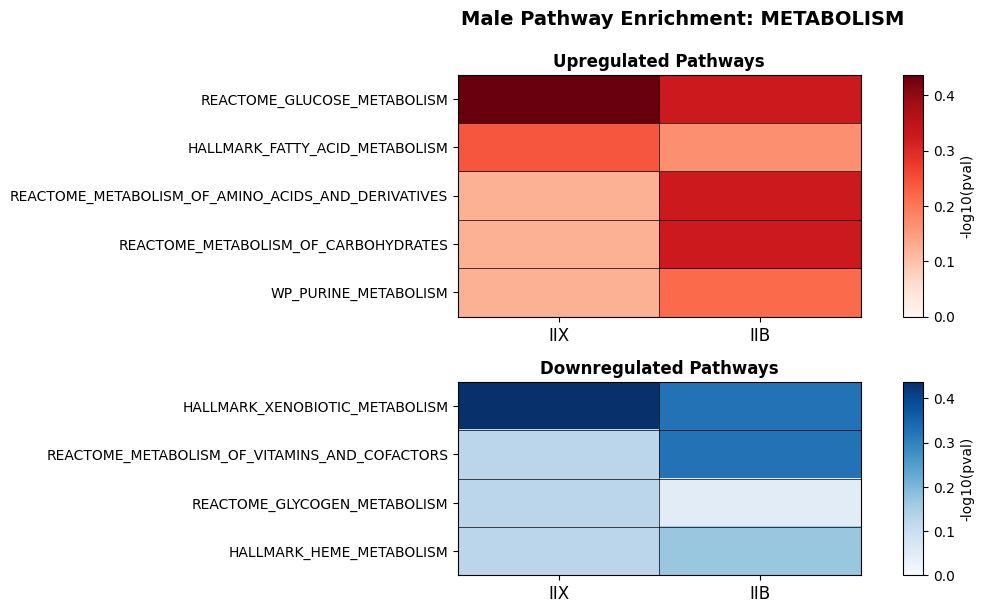

In [42]:
male_enriched_pathways = plot_pathway_heatmap(male_fastiix_plot_df, 
                     male_fastiib_plot_df, 
                     male_common_pathways, 
                     title=f"Male Pathway Enrichment: {PATHWAY_TYPE}")

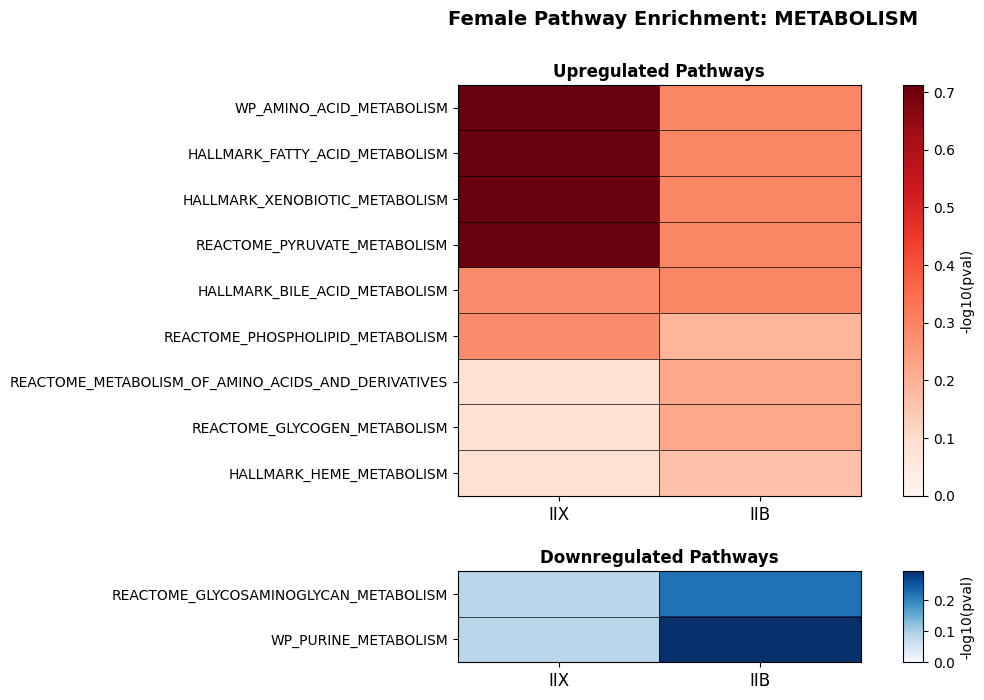

In [43]:
female_enriched_pathways = plot_pathway_heatmap(female_fastiix_plot_df, 
                     female_fastiib_plot_df, 
                     female_common_pathways, 
                     title=f"Female Pathway Enrichment: {PATHWAY_TYPE}")

# Save

In [49]:
# save as png
pgl.save_fig_as_png(male_enriched_pathways,
                    output_path=os.path.join(
                        OUTPUT_DIR,
                        "Male_IIX_IIB_Enriched_Pathways_PNG.png"
                    ))

pgl.save_fig_as_png(female_enriched_pathways,
                    output_path=os.path.join(
                        OUTPUT_DIR,
                        "Female_IIX_IIB_Enriched_Pathways_PNG.png"
                    ))

PosixPath('Output/Female_IIX_IIB_Enriched_Pathways_PNG.png')

In [48]:
# save as svg
pgl.save_editable_svg(male_enriched_pathways,
                    output_path=os.path.join(
                        OUTPUT_DIR,
                        "Male_IIX_IIB_Enriched_Pathways_SVG.svg"
                    ))

pgl.save_editable_svg(female_enriched_pathways,
                    output_path=os.path.join(
                        OUTPUT_DIR,
                        "Female_IIX_IIB_Enriched_Pathways_SVG.svg"
                    ))

PosixPath('Output/Female_IIX_IIB_Enriched_Pathways_SVG.svg')